In [1]:
# NB : This reload your library after each edit, 
# so you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

## Imports

In [ ]:
!pip install seaborn

In [ ]:
!pip install plotly

In [ ]:
!pip install scikit-learn

In [10]:
!pip install nbformat

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 2.6 MB/s eta 0:00:00
Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.8/390.8 kB 3.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# ML
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Loading Data

In [2]:
df_diamonds = sns.load_dataset('diamonds')

In [3]:
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df_diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [5]:
df_diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df_diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## Exploratory Data Analysis

<Axes: xlabel='price', ylabel='Count'>

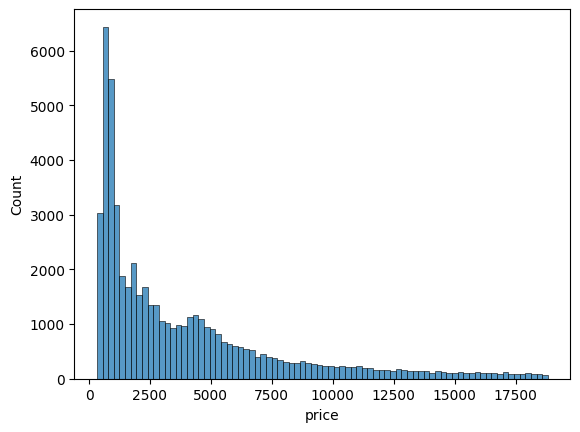

In [7]:
sns.histplot(data=df_diamonds,
             x="price")

In [8]:
px.scatter_3d(data_frame=df_diamonds,
              x="x",y="y",z="z", color="price")

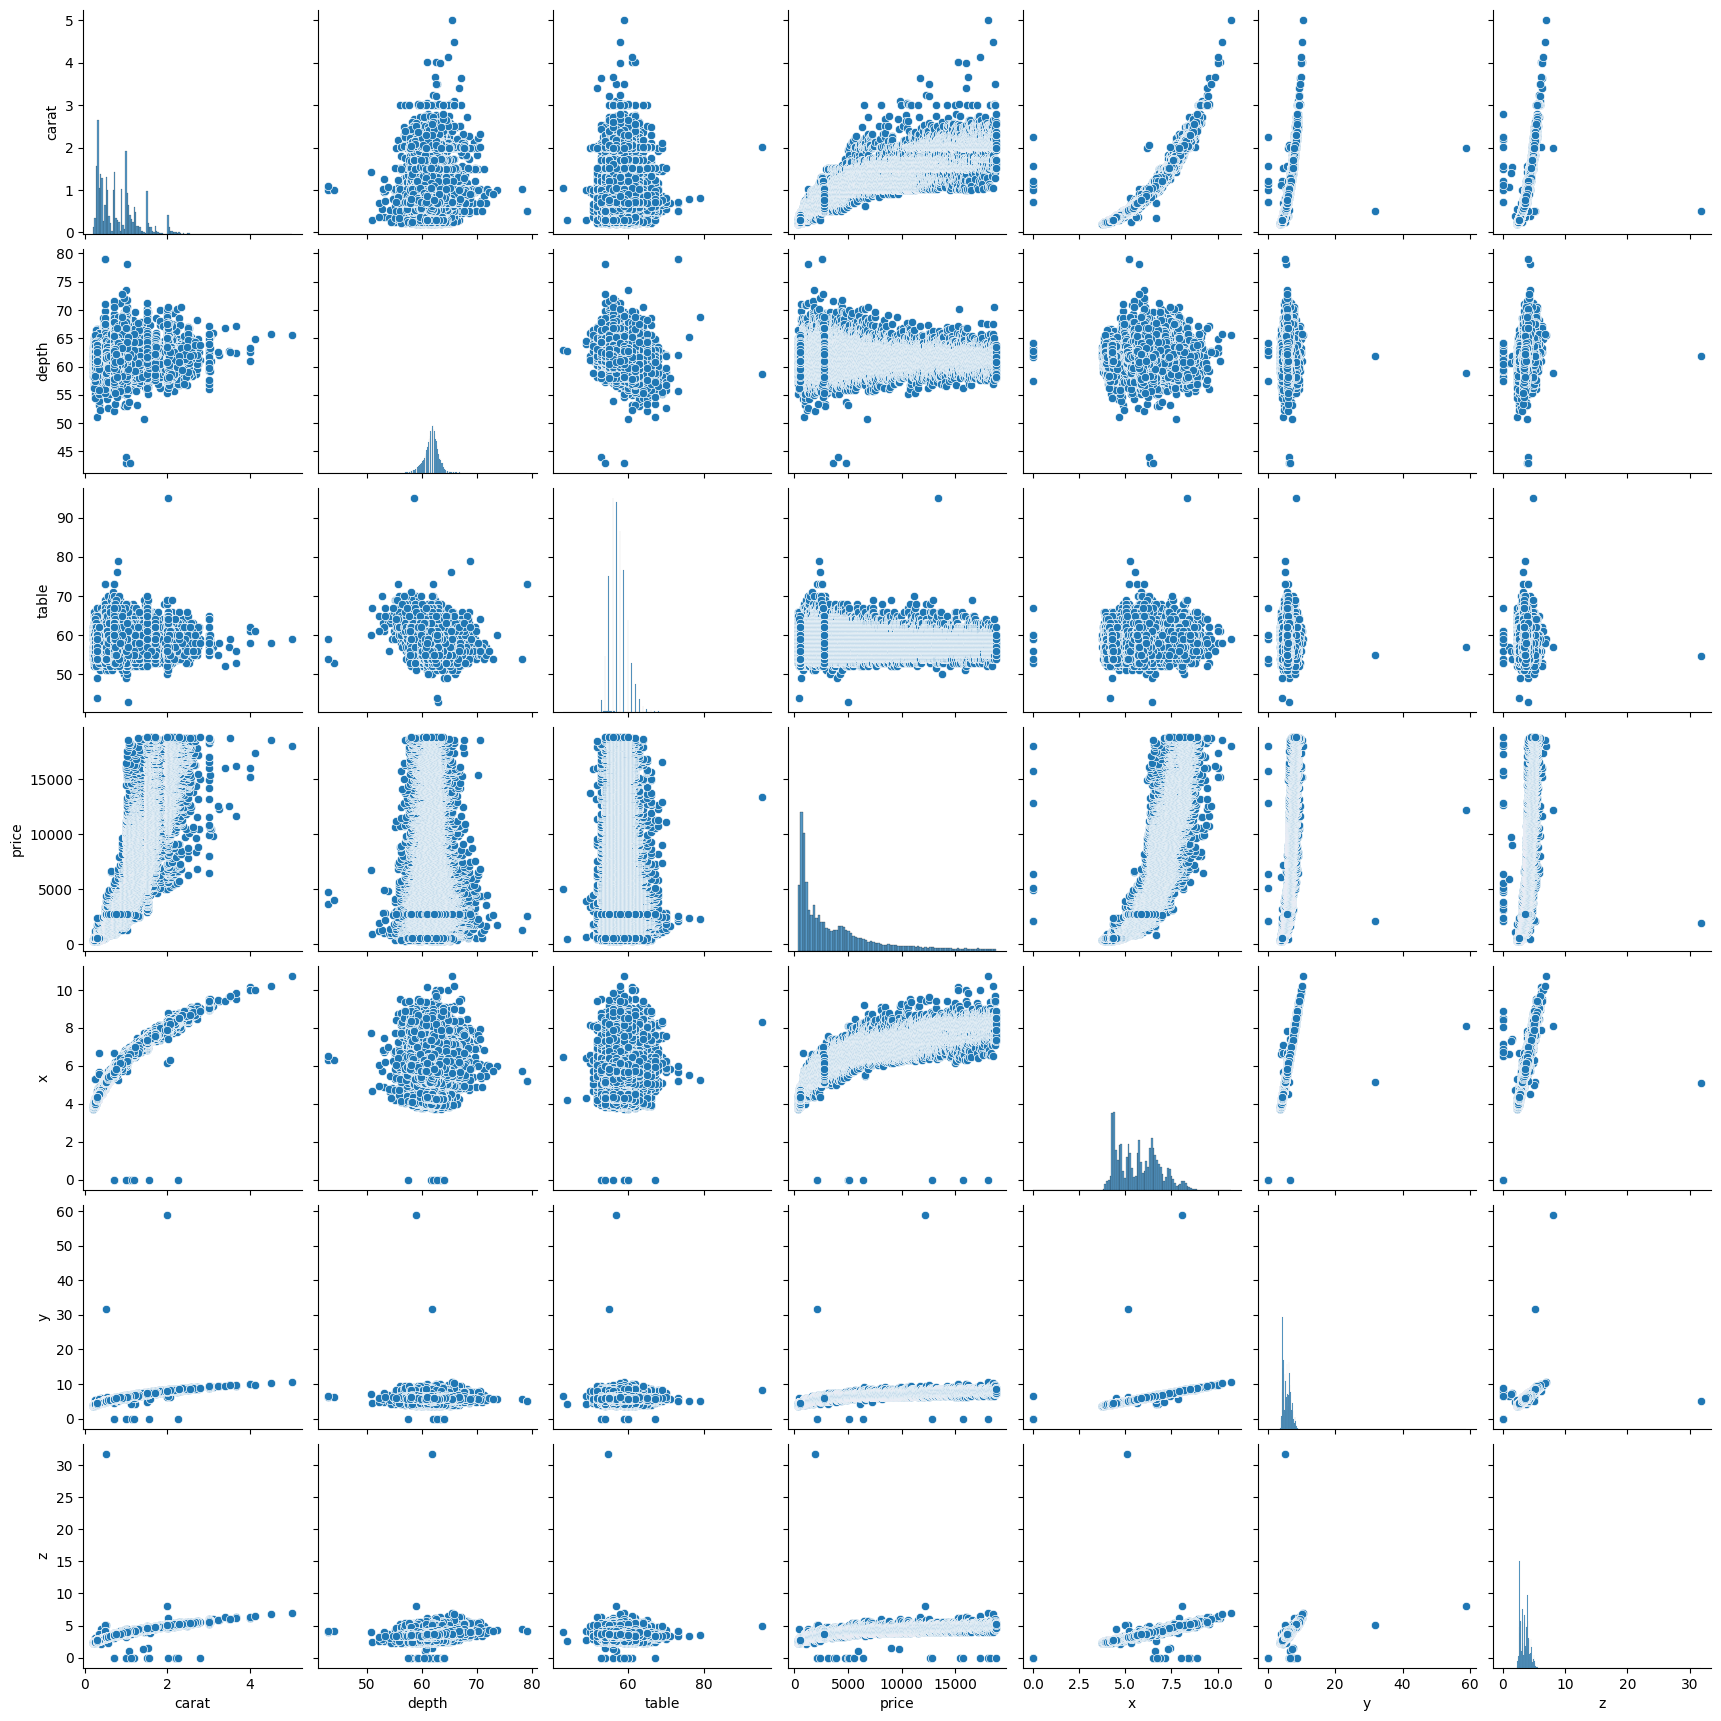

In [9]:
sns.pairplot(data=df_diamonds);

<Axes: >

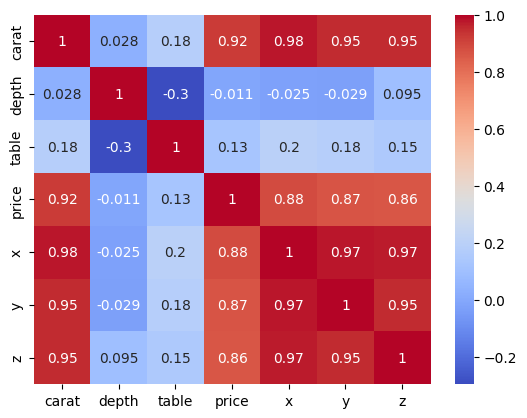

In [10]:
sns.heatmap(df_diamonds.select_dtypes(include="number").corr(),
           annot=True,
           cmap="coolwarm")

In [11]:
df_diamonds.select_dtypes(include="category")\
            ["color"].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

In [12]:
import scipy.stats as stats
groups = [group["price"].values for name, group in df_diamonds.groupby("color", observed=False)]


print("--- Test ANOVA à un facteur ---")
f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"Statistique F : {f_stat:.2f}")
print(f"P-value       : {p_value_anova:.2e}")

if p_value_anova < 0.05:
    print("Conclusion : On rejette H0. La couleur a un impact significatif sur le prix moyen.\n")
else:
    print("Conclusion : On ne peut pas rejeter H0. La couleur ne semble pas impacter le prix.\n")

--- Test ANOVA à un facteur ---
Statistique F : 290.21
P-value       : 0.00e+00
Conclusion : On rejette H0. La couleur a un impact significatif sur le prix moyen.



## Data Cleaning

In [13]:
def keep_not_null(row) :
    if 0 in row.values : return False
    return True

# Pour le test sur une ligne :
keep_not_null(df_diamonds.loc[11182,:])
    

False

In [14]:
df_clean = df_diamonds[df_diamonds.apply(keep_not_null,axis=1)]

In [15]:
df_clean[df_clean["x"] == 0]

,carat,cut,color,clarity,depth,table,price,x,y,z


## Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["price"])
y = df_clean["price"]

X_train, X_test, y_train, y_test  = train_test_split(X,y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40440, 9), (13480, 9), (40440,), (13480,))

## Data Preprocessing
### Categorical Data

In [17]:
df_cat = df_clean.select_dtypes(include="category")
df_cat.describe()

,cut,color,clarity
count,53920,53920,53920
unique,5,7,8
top,Ideal,G,SI1
freq,21548,11284,13063


In [18]:
cat_pipe = Pipeline(
    [ ("cat_imp",SimpleImputer(strategy="most_frequent"))
      ,("ohe",OneHotEncoder(drop="first",sparse_output=False))
        ])
cat_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cat_imp', ...), ('ohe', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

### Numerical Data

In [19]:
num_pipe = Pipeline(
    [("knn_imp", KNNImputer(n_neighbors=5))
     ,("scaler", StandardScaler())
      ])
num_pipe
    

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('knn_imp', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


## Final Preprocessor

In [20]:
preprocessor = ColumnTransformer(
    [("numeric",num_pipe, make_column_selector(dtype_include="number"))
    ,("categorical", cat_pipe, make_column_selector(dtype_exclude="number"))
      ]).set_output(transform="pandas")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [21]:

# Normalement j'ai pas besoin de preproc mais pour vérfier 
preprocessor.fit(X_train)
X_train_scaled = preprocessor.transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)

## Training 
### Trying a few models

In [22]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

df_clean["price"].max()

np.int64(18823)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true,y_pred) -> dict[float] : 
    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)
    r2  = r2_score(y_true,y_pred) 
    scores = {"mae":mae,"mse":mse,"r2":r2}
    print(scores)
    return scores
    

In [24]:
lin = LinearRegression()
lin.fit(X_train_scaled,y_train) 
y_pred = lin.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 722.46346893889, 'mse': 1276242.2307746315, 'r2': 0.9188877100527485}


{'mae': 722.46346893889, 'mse': 1276242.2307746315, 'r2': 0.9188877100527485}

In [25]:
forest = RandomForestRegressor()
forest.fit(X_train_scaled,y_train)
y_pred = forest.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 289.1994618879822, 'mse': 363761.4753338336, 'r2': 0.9768809356504297}


{'mae': 289.1994618879822, 'mse': 363761.4753338336, 'r2': 0.9768809356504297}

In [26]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled,y_train)
y_pred = knn.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 417.0538872403561, 'mse': 681395.7144094956, 'r2': 0.9566935136424289}


{'mae': 417.0538872403561, 'mse': 681395.7144094956, 'r2': 0.9566935136424289}

In [28]:
svm = SVR()
svm.fit(X_train_scaled,y_train)
y_pred = svm.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 1339.5945818836174, 'mse': 7871418.986713955, 'r2': 0.4997275566103807}


{'mae': 1339.5945818836174, 'mse': 7871418.986713955, 'r2': 0.4997275566103807}

In [ ]:
#! pip freeze | grep tensor

safetensors==0.6.2
tensorboard==2.20.0
tensorboard-data-server==0.7.2
tensorflow-datasets==4.9.9
tensorflow-estimator==2.15.0
tensorflow-io-gcs-filesystem==0.37.1
tensorflow-macos==2.15.1
tensorflow-metadata==1.17.2
tensorflow-metal==1.2.0


In [ ]:
# Bonus : Deep Learning model with Tensorflow

## Optimizing Hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = {"n_neighbors": range(2,30)}


search = GridSearchCV(KNeighborsRegressor(), grid, verbose=1)

search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': range(2, 30)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,4


In [ ]:
y_pred = search.predict(X_test_scaled)
print(search.best_params_)
evaluate_model(y_test,y_pred)

{'n_neighbors': 4}
{'mae': 417.14057863501483, 'mse': 672869.7432585312, 'r2': 0.9572353865153076}


{'mae': 417.14057863501483, 'mse': 672869.7432585312, 'r2': 0.9572353865153076}

In [ ]:
grid = {"n_estimators": [100,150,300,500]
        #,"max_depth" : [None, 2,5,10]
        #,"min_samples_leaf" : [1,5,10,50]
       }

search = GridSearchCV(RandomForestRegressor(),grid,verbose=1, cv=3)
search.fit(X_train_scaled,y_train)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5; 1/4] START n_estimators=100............................................
[CV 1/5; 1/4] END .............n_estimators=100;, score=0.974 total time=  13.0s
[CV 2/5; 1/4] START n_estimators=100............................................
[CV 3/5; 1/4] END .............n_estimators=100;, score=0.974 total time=  49.4s
[CV 4/5; 1/4] START n_estimators=100............................................
[CV 4/5; 1/4] END .............n_estimators=100;, score=0.974 total time=   9.7s
[CV 5/5; 1/4] START n_estimators=100............................................
[CV 5/5; 1/4] END .............n_estimators=100;, score=0.973 total time=   8.7s
[CV 1/5; 2/4] START n_estimators=150............................................
[CV 1/5; 2/4] END .............n_estimators=150;, score=0.974 total time=  13.1s
[CV 2/5; 2/4] START n_estimators=150............................................
[CV 2/5; 2/4] END .............n_estimators=150;,

,estimator,RandomForestRegressor()
,param_grid,"{'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [ ]:
y_pred = search.predict(X_test_scaled)
print(search.best_params_)
evaluate_model(y_test,y_pred)

{'n_estimators': 500}
{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}


{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}

### Final Train

In [ ]:
forest = RandomForestRegressor(**search.best_params_)
forest.fit(X_train_scaled,y_train)
y_pred = forest.predict(X_test_scaled)
evaluate_model(y_test,y_pred)

{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}


{'mae': 287.40844873567045, 'mse': 359848.7215501259, 'r2': 0.9771296129091376}

## Saving Model

In [ ]:
import pickle 
import os 

In [ ]:
! ls

Exploration.ipynb models


In [ ]:
# Saving the preprocessor 
model_path = "models"
if not os.path.exists(model_path) : 
    os.mkdir(model_path)
with open(os.path.join(model_path,"preproc.pkl"),"wb") as f:
    pickle.dump(preprocessor,f)

In [ ]:
# Saving the model 
with open(os.path.join(model_path,"model.pkl"),"wb")  as f:
    pickle.dump(forest,f)

In [ ]:
! tree

.
├── Exploration.ipynb
└── models
    ├── model.pkl
    └── preproc.pkl

2 directories, 3 files


## NB : Loading model

In [ ]:
with open(os.path.join(model_path,"preproc.pkl"),"rb")  as f:
    new_preproc = pickle.load(f)
new_preproc

,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
